# Social Media Engagement to Donation Conversion Pipeline

## 1. Problem Framing

**Business question:** Does stronger social media engagement in month *m* relate to higher donation totals in month *m+1*?

**Primary lens (explanatory):** estimate directional relationships between engagement activity and next-month donations.

**Comparison lens (predictive):** test whether a more flexible model improves out-of-sample forecasts for planning.

**Primary target:** next-month total **monetary donations** (`sum(amount)`).

**Sensitivity target:** next-month **estimated donation value** (`sum(estimated_value)`), to include non-monetary support value.

**Decision intent:** help leadership decide what to post, where to post, and how frequently to post when staffing is limited.

**Causality guardrail:** this is observational data, so results are associations, not proof of causation.


## Predictive and Explanatory Modeling Map

- **Predictive modeling**
  - Random Forest regression in **Section 3**
  - Chronological holdout performance in **Section 4**
- **Explanatory modeling**
  - Linear regression with standardized coefficients in **Section 3**
  - Relationship interpretation and cautions in **Section 5**

In short: **Linear Regression = explanatory readout**, **Random Forest = predictive comparison**.


## 2. Data Acquisition, Preparation & Exploration

We build an organization-month panel where social media features in month *m* predict donation outcomes in month *m+1*. We also create a platform-month panel for practical channel-level context.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    def display(x):
        if hasattr(x, "to_string"):
            print(x.to_string(index=False))
        else:
            print(x)

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

_cwd = Path.cwd()
candidate_dirs = [
    _cwd / "data",                # running from INTEX root
    _cwd.parent / "data",         # running from ml-pipelines
    _cwd / "INTEX" / "data",      # running from workspace root above INTEX
    _cwd.parent / "INTEX" / "data",
]

DATA_DIR = None
for d in candidate_dirs:
    if (d / "social_media_posts.csv").is_file() and (d / "donations.csv").is_file():
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find data/. Tried: ./data, ../data, ./INTEX/data, ../INTEX/data"
    )

print("Using DATA_DIR:", DATA_DIR)


Using DATA_DIR: g:\My Drive\Winter 2026\IS 455 - Machine Learning (MK)\INTEX\data


In [ ]:
social = pd.read_csv(DATA_DIR / "social_media_posts.csv")
donations = pd.read_csv(DATA_DIR / "donations.csv")

social["created_at"] = pd.to_datetime(social["created_at"], errors="coerce")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")

social = social.dropna(subset=["created_at"]).copy()
donations = donations.dropna(subset=["donation_date"]).copy()

social["month"] = social["created_at"].dt.to_period("M").dt.to_timestamp()
donations["month"] = donations["donation_date"].dt.to_period("M").dt.to_timestamp()

donations["amount"] = pd.to_numeric(donations["amount"], errors="coerce").fillna(0)
donations["estimated_value"] = pd.to_numeric(donations["estimated_value"], errors="coerce").fillna(0)

print("Social rows:", len(social), "| Donations rows:", len(donations))
print("Social month range:", social["month"].min().date(), "to", social["month"].max().date())
print("Donation month range:", donations["month"].min().date(), "to", donations["month"].max().date())


Social rows: 812 | Donations rows: 420
Social month range: 2023-01-01 to 2026-02-01
Donation month range: 2023-01-01 to 2026-03-01


In [ ]:
def build_org_month_features(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    x["is_weekend"] = x["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
    x["is_peak_hour"] = x["post_hour"].between(18, 22, inclusive="both").astype(int)

    base = x.groupby("month", as_index=False).agg(
        posts=("post_id", "count"),
        boosted_posts=("is_boosted", "sum"),
        boost_budget_php=("boost_budget_php", "sum"),
        likes=("likes", "sum"),
        comments=("comments", "sum"),
        shares=("shares", "sum"),
        forwards=("forwards", "sum"),
        click_throughs=("click_throughs", "sum"),
        avg_engagement_rate=("engagement_rate", "mean"),
        cta_rate=("has_call_to_action", "mean"),
        weekend_post_rate=("is_weekend", "mean"),
        peak_hour_post_rate=("is_peak_hour", "mean"),
    )

    post_mix = pd.crosstab(x["month"], x["post_type"], normalize="index").add_prefix("post_type_share_").reset_index()
    media_mix = pd.crosstab(x["month"], x["media_type"], normalize="index").add_prefix("media_share_").reset_index()
    topic_mix = pd.crosstab(x["month"], x["content_topic"], normalize="index").add_prefix("topic_share_").reset_index()

    out = base.merge(post_mix, on="month", how="left").merge(media_mix, on="month", how="left").merge(topic_mix, on="month", how="left")
    return out.fillna(0)


def build_targets(df: pd.DataFrame) -> pd.DataFrame:
    return df.groupby("month", as_index=False).agg(
        y_monetary_amount=("amount", "sum"),
        y_estimated_value=("estimated_value", "sum"),
        n_donation_events=("donation_id", "count"),
    )


org_feats = build_org_month_features(social)
org_targets = build_targets(donations)

panel = org_feats.merge(org_targets, on="month", how="left").sort_values("month").reset_index(drop=True)

# Align to next month target: X_m predicts Y_m+1
panel["y_next_monetary_amount"] = panel["y_monetary_amount"].shift(-1)
panel["y_next_estimated_value"] = panel["y_estimated_value"].shift(-1)

# Prior-month controls (known at month m)
panel["prev_monetary_amount"] = panel["y_monetary_amount"].shift(1)
panel["prev_estimated_value"] = panel["y_estimated_value"].shift(1)

panel["month_num"] = panel["month"].dt.month.astype(int)
panel["year_num"] = panel["month"].dt.year.astype(int)

# Keep months where next-month target exists
panel_model = panel.dropna(subset=["y_next_monetary_amount", "y_next_estimated_value"]).copy()

# Remove same-month outcome proxies from core feature set
leaky_or_outcome_like = {"y_monetary_amount", "y_estimated_value", "n_donation_events"}
feature_cols = [c for c in panel_model.columns if c not in {"month", "y_next_monetary_amount", "y_next_estimated_value"} | leaky_or_outcome_like]

print("Model rows:", len(panel_model), "| Feature columns:", len(feature_cols))
panel_model[["month", "y_next_monetary_amount", "y_next_estimated_value"]].head()


Model rows: 37 | Feature columns: 36


,month,y_next_monetary_amount,y_next_estimated_value
0,2023-01-01,2065.15,2104.13
1,2023-02-01,9577.83,11193.18
2,2023-03-01,5401.47,6819.25
3,2023-04-01,4862.09,5468.70
4,2023-05-01,1306.86,4899.13


### Feature glossary (generated fields)

Core modeling fields:
- `posts`: number of social posts in month *m*.
- `boosted_posts`: number of posts with paid boost in month *m*.
- `boost_budget_php`: total paid boost spending in month *m*.
- `avg_engagement_rate`: average post-level engagement rate in month *m*.
- `cta_rate`: share of posts with a call-to-action in month *m*.
- `weekend_post_rate`: share of posts made on Saturday/Sunday in month *m*.
- `peak_hour_post_rate`: share of posts made between 18:00 and 22:59 in month *m*.
- `engagement_index`: standardized monthly sum of `likes + comments + shares + forwards + click_throughs`; used for visualization/readability in the trend chart.
- `post_type_share_*`: fraction of month *m* posts by post type.
- `media_share_*`: fraction of month *m* posts by media format.
- `topic_share_*`: fraction of month *m* posts by content topic.
- `prev_monetary_amount`: total monetary donations in month *m-1*.
- `prev_estimated_value`: total estimated donation value in month *m-1*.
- `y_next_monetary_amount`: target monetary donations in month *m+1*.
- `y_next_estimated_value`: total estimated value across donation types in month *m+1*.


Chart explanation: Blue points show engagement during month m. Green points show donations one month later (month m+1).
The green series is shifted right by one month so the lag is visible on the calendar axis.


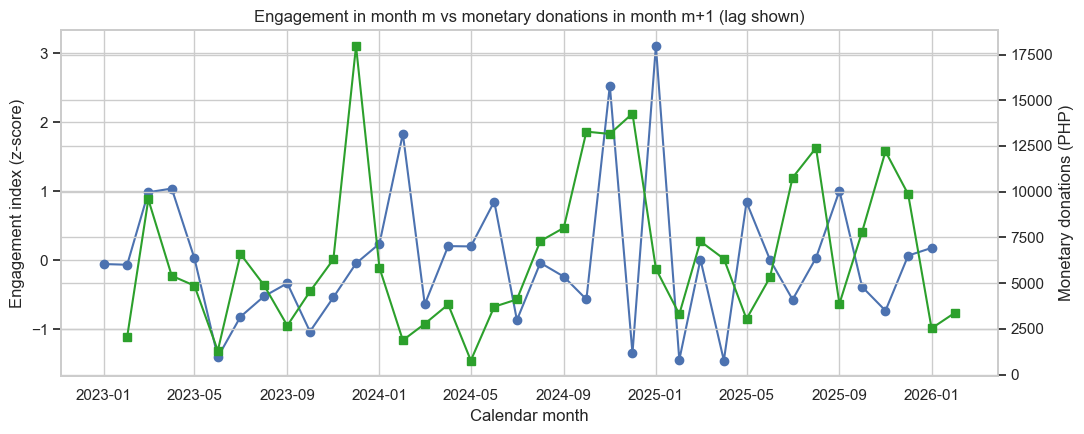

In [ ]:
# Chart 1: engagement index vs next-month monetary donations
plot_df = panel_model.copy()
engagement_index_raw = (
    plot_df[["likes", "comments", "shares", "forwards", "click_throughs"]]
    .fillna(0)
    .sum(axis=1)
)
plot_df["engagement_index"] = (engagement_index_raw - engagement_index_raw.mean()) / (engagement_index_raw.std(ddof=0) + 1e-9)

print("Chart explanation: Blue points show engagement during month m. Green points show donations one month later (month m+1).")
print("The green series is shifted right by one month so the lag is visible on the calendar axis.")

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(plot_df["month"], plot_df["engagement_index"], marker="o", label="Engagement in month m (z-score)")
ax1.set_ylabel("Engagement index (z-score)")
ax1.set_xlabel("Calendar month")

ax2 = ax1.twinx()
ax2.plot(plot_df["month"] + pd.offsets.MonthBegin(1), plot_df["y_next_monetary_amount"], marker="s", color="tab:green", label="Monetary donations in month m+1")
ax2.set_ylabel("Monetary donations (PHP)")

ax1.set_title("Engagement in month m vs monetary donations in month m+1 (lag shown)")
fig.tight_layout()
plt.show()


Chart explanation: Each dot is one platform-month.
Farther right means higher engagement in month m; higher up means higher total donations in month m+1.


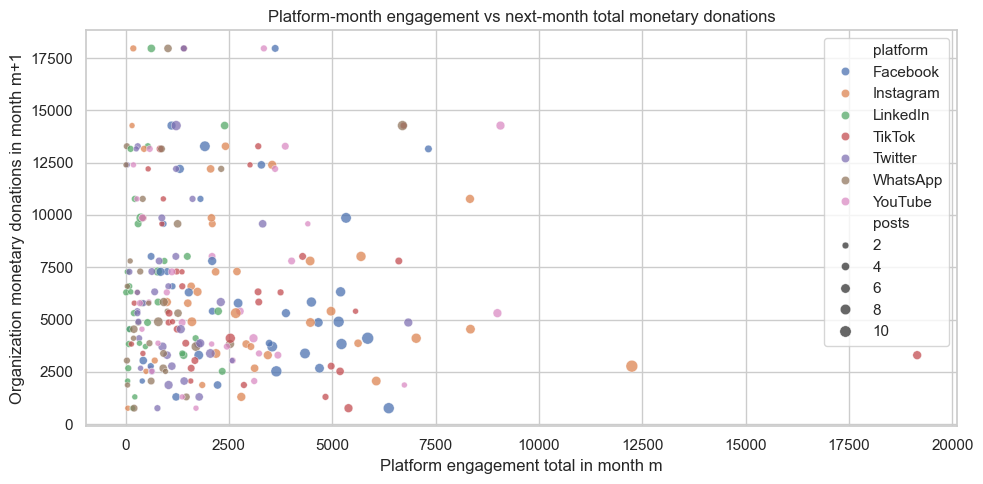

In [ ]:
# Secondary context: platform-month panel for strategy discussion
platform_month = (
    social.groupby(["month", "platform"], as_index=False)
    .agg(
        posts=("post_id", "count"),
        likes=("likes", "sum"),
        comments=("comments", "sum"),
        shares=("shares", "sum"),
        forwards=("forwards", "sum"),
        click_throughs=("click_throughs", "sum"),
    )
)
platform_month["engagement_total"] = platform_month[["likes", "comments", "shares", "forwards", "click_throughs"]].sum(axis=1)
platform_month = platform_month.merge(org_targets[["month", "y_monetary_amount"]], on="month", how="left")
platform_month["y_next_monetary_amount"] = platform_month.groupby("platform")["y_monetary_amount"].shift(-1)
platform_month = platform_month.dropna(subset=["y_next_monetary_amount"]).copy()

print("Chart explanation: Each dot is one platform-month.")
print("Farther right means higher engagement in month m; higher up means higher total donations in month m+1.")

if sns is not None:
    plt.figure(figsize=(10, 5))
    sns.scatterplot(
        data=platform_month,
        x="engagement_total",
        y="y_next_monetary_amount",
        hue="platform",
        size="posts",
        alpha=0.75,
    )
    plt.title("Platform-month engagement vs next-month total monetary donations")
    plt.xlabel("Platform engagement total in month m")
    plt.ylabel("Organization monetary donations in month m+1")
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(10, 5))
    plt.scatter(platform_month["engagement_total"], platform_month["y_next_monetary_amount"], alpha=0.65)
    plt.title("Platform-month engagement vs next-month donations")
    plt.xlabel("Platform engagement total in month m")
    plt.ylabel("Organization donations in month m+1")
    plt.tight_layout()
    plt.show()


Chart explanation: Each panel is one platform. The line shows a simple linear trend.
R^2 near 0 means weak linear relationship; higher R^2 means a stronger linear fit in this dataset.


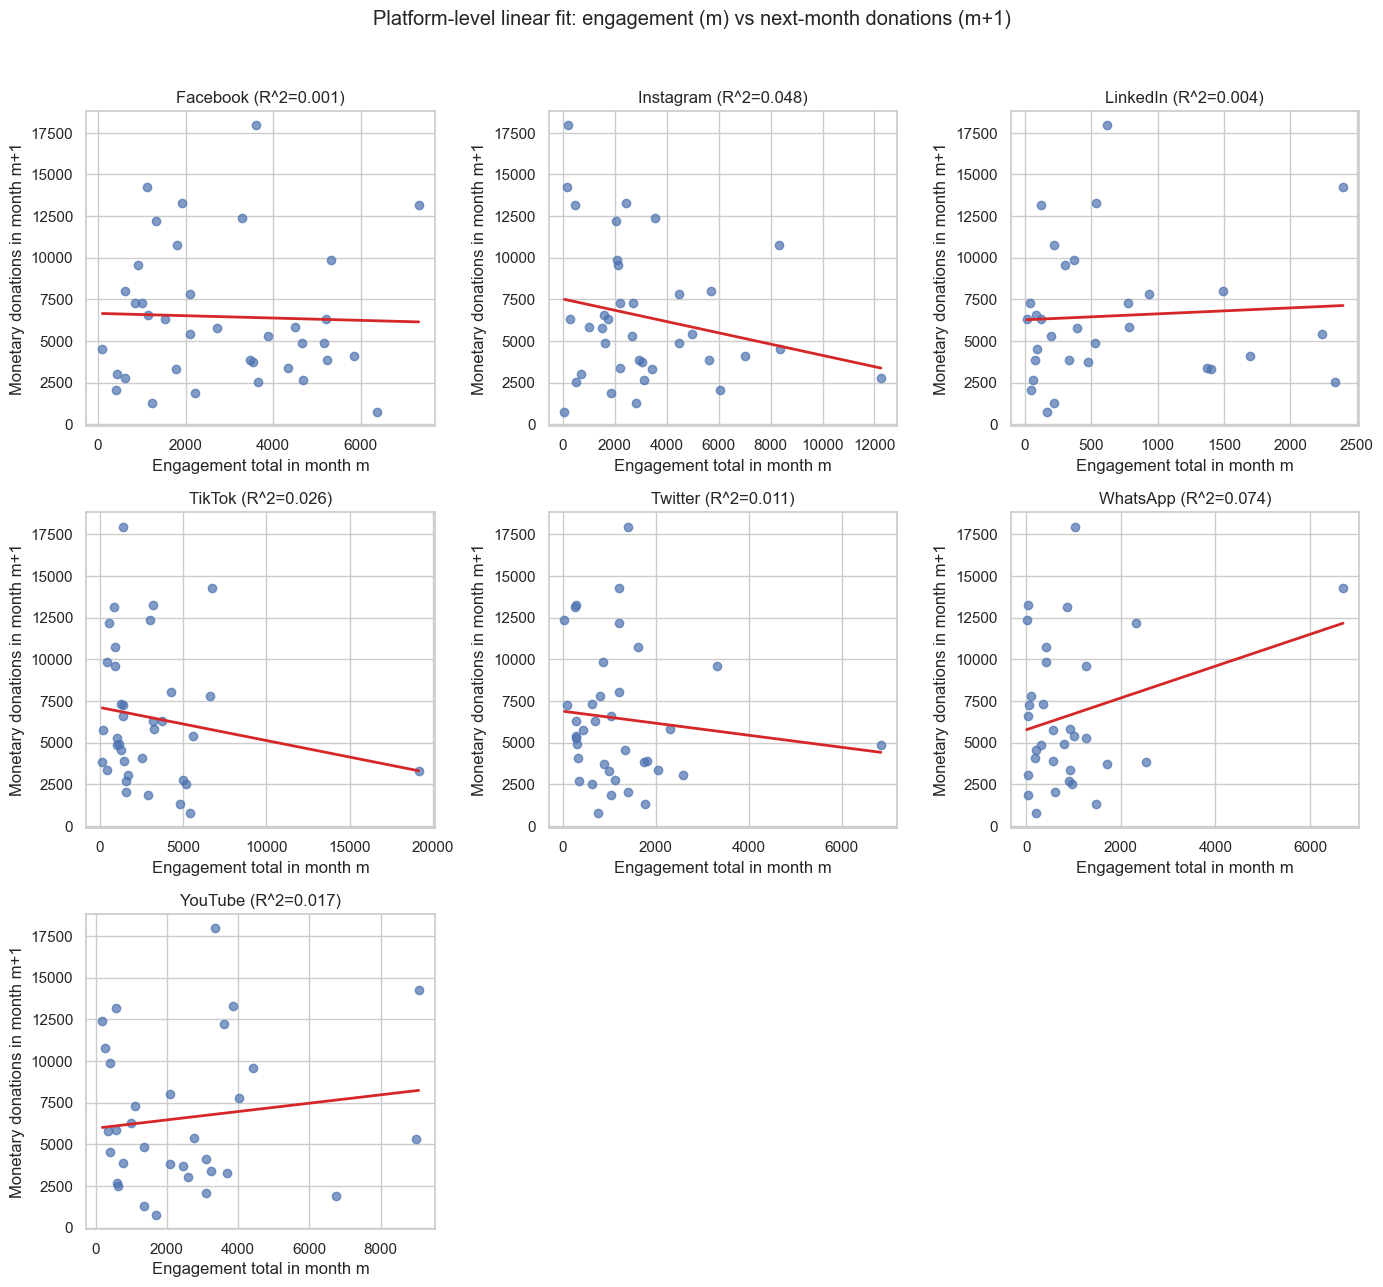

Per-platform linear fit strength (R^2):
 platform  n_points       r2
 WhatsApp        32 0.074350
Instagram        37 0.048355
   TikTok        36 0.025905
  YouTube        32 0.017471
  Twitter        37 0.011252
 LinkedIn        31 0.004066
 Facebook        37 0.001092

Interpretation tip:
- Very low R^2 values mean this chart should be read as descriptive context, not strong predictive evidence.


In [ ]:
# Regression-line view: platform engagement vs next-month donations
print("Chart explanation: Each panel is one platform. The line shows a simple linear trend.")
print("R^2 near 0 means weak linear relationship; higher R^2 means a stronger linear fit in this dataset.")

platforms = sorted(platform_month["platform"].dropna().unique().tolist())
r2_rows = []

n_cols = 3
n_rows = int(np.ceil(len(platforms) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.2 * n_rows), squeeze=False)

for idx, platform in enumerate(platforms):
    r, c = divmod(idx, n_cols)
    ax = axes[r][c]
    d = platform_month[platform_month["platform"] == platform].copy()

    x = d["engagement_total"].astype(float)
    y = d["y_next_monetary_amount"].astype(float)

    ax.scatter(x, y, alpha=0.7)

    if len(d) >= 3 and x.nunique() > 1:
        slope, intercept = np.polyfit(x, y, 1)
        y_hat = slope * x + intercept
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
        xx = np.linspace(x.min(), x.max(), 100)
        ax.plot(xx, slope * xx + intercept, color="tab:red", linewidth=2)
    else:
        r2 = np.nan

    r2_rows.append({"platform": platform, "n_points": len(d), "r2": r2})
    r2_label = "NA" if pd.isna(r2) else f"{r2:.3f}"
    ax.set_title(f"{platform} (R^2={r2_label})")
    ax.set_xlabel("Engagement total in month m")
    ax.set_ylabel("Monetary donations in month m+1")

# Hide any unused subplot slots
for j in range(len(platforms), n_rows * n_cols):
    r, c = divmod(j, n_cols)
    axes[r][c].axis("off")

fig.suptitle("Platform-level linear fit: engagement (m) vs next-month donations (m+1)", y=1.02)
fig.tight_layout()
plt.show()

r2_table = pd.DataFrame(r2_rows).sort_values("r2", ascending=False)
print("Per-platform linear fit strength (R^2):")
display(r2_table)

print("\nInterpretation tip:")
print("- Very low R^2 values mean this chart should be read as descriptive context, not strong predictive evidence.")

## 3. Modeling & Feature Selection

We train two models on the same chronological split:
- **Explanatory model:** linear regression (interpretable directional associations)
- **Comparison predictive model:** random forest regression (captures non-linear relationships)

All preprocessing is inside sklearn `ColumnTransformer` + `Pipeline` so the workflow is reproducible.


In [ ]:
model_df = panel_model.copy().sort_values("month").reset_index(drop=True)
split_idx = int(len(model_df) * 0.75)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df["y_next_monetary_amount"].copy()
y_test = test_df["y_next_monetary_amount"].copy()

numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(model_df[c])]
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ]
)

lin_model = Pipeline([("prep", preprocess), ("model", LinearRegression())])
rf_model = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=350, max_depth=8, min_samples_leaf=2, random_state=42)),
])

lin_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Train months:", train_df["month"].min().date(), "to", train_df["month"].max().date())
print("Test months:", test_df["month"].min().date(), "to", test_df["month"].max().date())


Train months: 2023-01-01 to 2025-03-01
Test months: 2025-04-01 to 2026-01-01


## 4. Evaluation & Interpretation

Evaluation uses a chronological holdout to mirror real forecasting. We compare models using MAE, RMSE, and R².


In [ ]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

pred_lin = lin_model.predict(X_test)
pred_rf = rf_model.predict(X_test)

metrics = pd.DataFrame(
    [
        {
            "model": "Linear Regression (explanatory)",
            "MAE": mean_absolute_error(y_test, pred_lin),
            "RMSE": rmse(y_test, pred_lin),
            "R2": r2_score(y_test, pred_lin),
        },
        {
            "model": "Random Forest (predictive)",
            "MAE": mean_absolute_error(y_test, pred_rf),
            "RMSE": rmse(y_test, pred_rf),
            "R2": r2_score(y_test, pred_rf),
        },
    ]
).sort_values("RMSE")

display(metrics)

print(f"\nBusiness readout:")
print("- MAE is the average pesos we miss by in next-month donation forecasts.")
print("- Lower RMSE means fewer large forecasting misses.")
print("- Overestimation can cause over-budgeting campaign plans; underestimation can cause missed outreach opportunities.")


                          model         MAE        RMSE        R2
     Random Forest (predictive) 2857.601724 3516.826482  0.119435
Linear Regression (explanatory) 7582.278574 8176.186180 -3.759497

Business readout:
- MAE is the average pesos we miss by in next-month donation forecasts.
- Lower RMSE means fewer large forecasting misses.
- Overestimation can cause over-budgeting campaign plans; underestimation can cause missed outreach opportunities.


In [ ]:
# Sensitivity check: same setup for estimated value target
y_train_sens = train_df["y_next_estimated_value"].copy()
y_test_sens = test_df["y_next_estimated_value"].copy()

lin_model_s = Pipeline([("prep", preprocess), ("model", LinearRegression())])
rf_model_s = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=350, max_depth=8, min_samples_leaf=2, random_state=42)),
])

lin_model_s.fit(X_train, y_train_sens)
rf_model_s.fit(X_train, y_train_sens)

pred_lin_s = lin_model_s.predict(X_test)
pred_rf_s = rf_model_s.predict(X_test)

sens_metrics = pd.DataFrame(
    [
        {
            "model": "Linear Regression (explanatory)",
            "MAE": mean_absolute_error(y_test_sens, pred_lin_s),
            "RMSE": rmse(y_test_sens, pred_lin_s),
            "R2": r2_score(y_test_sens, pred_lin_s),
        },
        {
            "model": "Random Forest (predictive)",
            "MAE": mean_absolute_error(y_test_sens, pred_rf_s),
            "RMSE": rmse(y_test_sens, pred_rf_s),
            "R2": r2_score(y_test_sens, pred_rf_s),
        },
    ]
).sort_values("RMSE")

display(sens_metrics)


                          model         MAE        RMSE        R2
     Random Forest (predictive) 3053.613793 3652.231834  0.218449
Linear Regression (explanatory) 7356.529337 7901.463259 -2.658100


### Reliability Checks

We keep this simple and practical:
- compare models against naive baselines,
- validate with walk-forward time splits,
- run a log-target check to reduce outlier impact.


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

# Keep a small, easy-to-explain feature set for the explanatory model
core_features = [
    "posts",
    "shares",
    "click_throughs",
    "cta_rate",
    "boost_budget_php",
    "prev_monetary_amount",
    "month_num",
]
core_features = [c for c in core_features if c in model_df.columns]

core_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), core_features),
    ]
)

ridge_core = Pipeline([("prep", core_preprocess), ("model", Ridge(alpha=1.0))])
ridge_core.fit(train_df[core_features], y_train)
ridge_holdout_pred = ridge_core.predict(test_df[core_features])

print("Core features:", core_features)


Core features: ['posts', 'shares', 'click_throughs', 'cta_rate', 'boost_budget_php', 'prev_monetary_amount', 'month_num']


In [ ]:
# Compare to simple baselines on the holdout window
baseline_last_month = test_df["prev_monetary_amount"].fillna(train_df["y_next_monetary_amount"].mean())
baseline_train_mean = pd.Series(train_df["y_next_monetary_amount"].mean(), index=test_df.index)

def score_block(name, y_true, y_pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

holdout_compare = pd.DataFrame([
    score_block("Naive (last month)", y_test, baseline_last_month),
    score_block("Naive (train mean)", y_test, baseline_train_mean),
    score_block("Linear Regression", y_test, pred_lin),
    score_block("Random Forest", y_test, pred_rf),
    score_block("Ridge (core features)", y_test, ridge_holdout_pred),
]).sort_values("RMSE")

print("Holdout results (lower MAE/RMSE is better):")
display(holdout_compare)
print("\nMost reliable holdout model:", holdout_compare.iloc[0]["model"])

# Quick walk-forward check for Ridge stability over time
X_all = model_df[core_features].reset_index(drop=True)
y_all = model_df["y_next_monetary_amount"].reset_index(drop=True)
tscv = TimeSeriesSplit(n_splits=5)
wf_rmse = []

for tr_idx, te_idx in tscv.split(X_all):
    model_fold = clone(ridge_core)
    model_fold.fit(X_all.iloc[tr_idx], y_all.iloc[tr_idx])
    pred_fold = model_fold.predict(X_all.iloc[te_idx])
    wf_rmse.append(rmse(y_all.iloc[te_idx], pred_fold))

print("Walk-forward RMSE by fold:", [round(x, 2) for x in wf_rmse])
print("Walk-forward average RMSE:", round(float(np.mean(wf_rmse)), 2))

Holdout results (lower MAE/RMSE is better):
                model         MAE        RMSE        R2
        Random Forest 2857.601724 3516.826482  0.119435
   Naive (train mean) 3489.543000 3854.397504 -0.057724
Ridge (core features) 3326.499059 4018.329685 -0.149610
   Naive (last month) 5810.534000 6378.050697 -1.896246
    Linear Regression 7582.278574 8176.186180 -3.759497

Most reliable holdout model: Random Forest
Walk-forward RMSE by fold: [6237.21, 3432.44, 4762.94, 3628.55, 4928.22]
Walk-forward average RMSE: 4597.87


In [ ]:
# Log-target robustness check (reduces impact of extreme donation months)
y_train_log = np.log1p(train_df["y_next_monetary_amount"])
y_test_log = np.log1p(test_df["y_next_monetary_amount"])

ridge_log = Pipeline([
    ("prep", core_preprocess),
    ("model", Ridge(alpha=1.0))
])
ridge_log.fit(train_df[core_features], y_train_log)

pred_log = ridge_log.predict(test_df[core_features])
pred_log_back = np.expm1(pred_log)

print("Log-target Ridge holdout metrics (reported in original peso scale):")
print({
    "MAE": round(mean_absolute_error(y_test, pred_log_back), 2),
    "RMSE": round(rmse(y_test, pred_log_back), 2),
    "R2": round(r2_score(y_test, pred_log_back), 4),
})

Log-target Ridge holdout metrics (reported in original peso scale):
{'MAE': 3773.92, 'RMSE': 4424.72, 'R2': -0.3939}


In [ ]:
# Simple explanatory readout from the Ridge model (easier to interpret)
coef_names = ridge_core.named_steps["prep"].get_feature_names_out()
coef_vals = ridge_core.named_steps["model"].coef_
coef_table = pd.DataFrame({"feature": coef_names, "coefficient": coef_vals})
coef_table["abs_coef"] = coef_table["coefficient"].abs()

print("Top explanatory signals (Ridge, absolute size):")
display(coef_table.sort_values("abs_coef", ascending=False).head(8)[["feature", "coefficient"]])
print("\nNote: coefficient sign shows direction of association, not causation.")

Top explanatory signals (Ridge, absolute size):
                  feature  coefficient
           num__month_num  2975.459278
              num__shares  2383.570944
               num__posts -2255.562330
            num__cta_rate   943.109229
num__prev_monetary_amount  -893.147234
      num__click_throughs   535.442701
    num__boost_budget_php  -282.407553

Note: coefficient sign shows direction of association, not causation.


## 5. Causal and Relationship Analysis

This section focuses on explanatory interpretation from the linear model.


In [ ]:
prep_fitted = lin_model.named_steps["prep"]
feature_names = prep_fitted.get_feature_names_out()
coefs = lin_model.named_steps["model"].coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
coef_top = coef_df.sort_values("abs_coef", ascending=False).head(12)
display(coef_top[["feature", "coef"]])

print(f"\nInterpretation guide:")
print("- Positive coefficient: feature is associated with higher next-month monetary donations, all else held constant in this model.")
print("- Negative coefficient: feature is associated with lower next-month monetary donations.")
print("- These are associations from historical patterns, not causal proof.")


                                feature         coef
                             num__posts -2203.421418
      num__topic_share_AwarenessRaising  1774.194094
                          num__forwards  1714.353649
                     num__boosted_posts  1557.373225
num__post_type_share_EducationalContent  1525.761751
          num__post_type_share_ThankYou  1454.745461
                             num__likes -1452.975528
 num__post_type_share_FundraisingAppeal -1449.877213
    num__post_type_share_EventPromotion -1446.021717
             num__topic_share_Gratitude  1388.615377
               num__avg_engagement_rate -1353.487398
              num__media_share_Carousel  1302.804339

Interpretation guide:
- Positive coefficient: feature is associated with higher next-month monetary donations, all else held constant in this model.
- Negative coefficient: feature is associated with lower next-month monetary donations.
- These are associations from historical patterns, not causal proof.


## 6. Deployment Notes

**How to operationalize in the web app:**
- Run this pipeline monthly after social metrics close for month *m*.
- Feed month *m* social features into the most reliable validated model (lowest RMSE with acceptable walk-forward consistency) to forecast month *m+1* donations.
- Show a simple dashboard card with (1) expected next-month donations, (2) confidence note based on validation error, and (3) top actionable engagement levers from the explanatory model.
- Keep candidate models in versioned artifacts and re-check reliability each month as new data arrives.

**Synthesis (predictive vs explanatory):**
- Explanatory model provides clearer directional guidance (what seems associated with better next-month funding).
- Predictive model provides a practical forecast benchmark for planning.
- Use both together: explanatory for strategy design, predictive for monthly planning.

**Limitations:**
- Observational data cannot confirm causation.
- Month-level sample size is limited.
- External factors (seasonality, macro events, campaign timing) may still drive part of donation movement.


### Actionable Social Media Playbook (from observed data)

This block answers the core operating questions with simple ranked recommendations:
- what to post,
- where to post,
- when to post,
- how often to post,
- and what appears to convert (not just generate likes).

All outputs below are descriptive historical performance, so treat them as decision support and re-check monthly.


### Playbook KPI glossary

- `total_reach`: total number of unique accounts reached in the grouped slice.
- `total_likes`: total likes/reactions in the grouped slice.
- `total_referrals`: total donation referrals in the grouped slice.
- `total_est_value`: total estimated donation value (PHP) in the grouped slice.
- `likes_per_1000_reach`: likes normalized by reach, calculated as `1000 * total_likes / total_reach`.
- `referrals_per_1000_reach`: donation referrals normalized by reach, calculated as `1000 * total_referrals / total_reach`.
- `value_per_1000_reach`: estimated donation value normalized by reach, calculated as `1000 * total_est_value / total_reach`.
- `referrals_per_post`: average donation referrals generated per post, `total_referrals / posts`.
- `value_per_post`: average estimated donation value generated per post (PHP), `total_est_value / posts`.
- `posts_per_week`: approximate posting cadence in a month, `posts / 4.3`.
- `cadence_band`: posting-frequency bucket (`0-1/week`, `1-2/week`, `2-4/week`, `4+/week`).
- `hour_bucket`: posting time bucket (`Late Night`, `Morning`, `Afternoon`, `Evening`).


In [ ]:
# Build practical conversion-efficiency views
play = social.copy()
play["reach"] = pd.to_numeric(play["reach"], errors="coerce").fillna(0)
play["likes"] = pd.to_numeric(play["likes"], errors="coerce").fillna(0)
play["donation_referrals"] = pd.to_numeric(play["donation_referrals"], errors="coerce").fillna(0)
play["estimated_donation_value_php"] = pd.to_numeric(play["estimated_donation_value_php"], errors="coerce").fillna(0)

# Time buckets for easy scheduling decisions
play["hour_bucket"] = pd.cut(
    play["post_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Late Night (0-5)", "Morning (6-11)", "Afternoon (12-17)", "Evening (18-23)"]
)

# Conversion-focused KPI helper

def summarize_efficiency(df, group_cols):
    out = df.groupby(group_cols, as_index=False, observed=True).agg(
        posts=("post_id", "count"),
        total_reach=("reach", "sum"),
        total_likes=("likes", "sum"),
        total_referrals=("donation_referrals", "sum"),
        total_est_value=("estimated_donation_value_php", "sum"),
    )
    out["likes_per_1000_reach"] = np.where(out["total_reach"] > 0, 1000 * out["total_likes"] / out["total_reach"], np.nan)
    out["referrals_per_1000_reach"] = np.where(out["total_reach"] > 0, 1000 * out["total_referrals"] / out["total_reach"], np.nan)
    out["value_per_1000_reach"] = np.where(out["total_reach"] > 0, 1000 * out["total_est_value"] / out["total_reach"], np.nan)
    out["referrals_per_post"] = np.where(out["posts"] > 0, out["total_referrals"] / out["posts"], np.nan)
    out["value_per_post"] = np.where(out["posts"] > 0, out["total_est_value"] / out["posts"], np.nan)
    return out

platform_tbl = summarize_efficiency(play, ["platform"]).query("posts >= 20").sort_values("referrals_per_1000_reach", ascending=False)
content_tbl = summarize_efficiency(play, ["post_type", "content_topic"]).query("posts >= 12").sort_values("referrals_per_post", ascending=False)
time_tbl = summarize_efficiency(play, ["platform", "hour_bucket"]).query("posts >= 8").sort_values(["platform", "referrals_per_post"], ascending=[True, False])

# Posting frequency view (how often)
pm = play.groupby(["platform", "month"], as_index=False).agg(
    posts=("post_id", "count"),
    referrals=("donation_referrals", "sum"),
    est_value=("estimated_donation_value_php", "sum"),
)
pm["posts_per_week"] = pm["posts"] / 4.3
pm["cadence_band"] = pd.cut(
    pm["posts_per_week"],
    bins=[-0.01, 1, 2, 4, 20],
    labels=["0-1/week", "1-2/week", "2-4/week", "4+/week"],
)

# observed=True avoids cartesian category expansion issues in some pandas versions
cadence_tbl = (
    pm.groupby(["platform", "cadence_band"], observed=True)
    .agg(
        months_observed=("month", "count"),
        avg_referrals_per_month=("referrals", "mean"),
        avg_value_per_month=("est_value", "mean"),
    )
    .reset_index()
    .query("months_observed >= 3")
    .sort_values(["platform", "avg_referrals_per_month"], ascending=[True, False])
)

try:
    from IPython.display import display
except ImportError:
    display = print

print("Top platforms by conversion efficiency (minimum 20 posts):")
display(platform_tbl[["platform", "posts", "referrals_per_1000_reach", "value_per_1000_reach", "likes_per_1000_reach"]].head(6))

print("\nTop content combinations by referrals per post (minimum 12 posts):")
display(content_tbl[["post_type", "content_topic", "posts", "referrals_per_post", "value_per_post"]].head(8))

print("\nBest posting windows by platform (conversion over likes):")
display(time_tbl[["platform", "hour_bucket", "posts", "referrals_per_post", "likes_per_1000_reach"]].groupby("platform").head(2))

print("\nCadence guide (average referral/value output by posting frequency):")
display(cadence_tbl[["platform", "cadence_band", "months_observed", "avg_referrals_per_month", "avg_value_per_month"]])

Top platforms by conversion efficiency (minimum 20 posts):


,platform,posts,referrals_per_1000_reach,value_per_1000_reach,likes_per_1000_reach
5,WhatsApp,93,15.968717,54230.765800,87.679258
0,Facebook,199,3.255341,9254.610167,87.761056
3,TikTok,89,2.865948,8417.958803,94.307799
1,Instagram,164,2.833563,7583.399917,93.561292
6,YouTube,71,2.759569,8166.364263,86.313940
4,Twitter,117,2.593593,6441.189271,92.940949



Top content combinations by referrals per post (minimum 12 posts):


,post_type,content_topic,posts,referrals_per_post,value_per_post
43,ImpactStory,Reintegration,19,46.684211,143827.136316
42,ImpactStory,Health,25,46.600000,155088.917600
44,ImpactStory,SafehouseLife,37,43.081081,146798.551081
37,ImpactStory,CampaignLaunch,15,37.533333,105654.457333
41,ImpactStory,Gratitude,25,35.520000,78327.180800
36,ImpactStory,AwarenessRaising,19,35.473684,126749.650526
38,ImpactStory,DonorImpact,23,31.521739,122101.288696
39,ImpactStory,Education,31,25.064516,79444.783548



Best posting windows by platform (conversion over likes):


,platform,hour_bucket,posts,referrals_per_post,likes_per_1000_reach
1,Facebook,Morning (6-11),53,22.301887,102.904550
3,Facebook,Evening (18-23),70,10.314286,95.180119
6,Instagram,Afternoon (12-17),50,17.820000,98.265854
7,Instagram,Evening (18-23),50,13.060000,112.692682
9,LinkedIn,Morning (6-11),30,8.600000,103.315116
10,LinkedIn,Afternoon (12-17),22,2.909091,67.184587
15,TikTok,Evening (18-23),32,34.000000,138.184529
13,TikTok,Morning (6-11),20,18.450000,47.062289
17,Twitter,Morning (6-11),40,8.450000,98.544139
19,Twitter,Evening (18-23),32,6.468750,102.239672



Cadence guide (average referral/value output by posting frequency):


,platform,cadence_band,months_observed,avg_referrals_per_month,avg_value_per_month
2,Facebook,2-4/week,5,105.200000,263234.196000
1,Facebook,1-2/week,17,56.352941,159603.524706
0,Facebook,0-1/week,16,43.250000,134795.045000
4,Instagram,1-2/week,16,72.937500,204197.635000
3,Instagram,0-1/week,21,26.523810,58881.083333
6,LinkedIn,0-1/week,30,11.066667,90845.800000
9,TikTok,1-2/week,3,165.333333,552961.146667
8,TikTok,0-1/week,34,36.588235,101526.572647
11,Twitter,1-2/week,9,27.888889,66661.178889
10,Twitter,0-1/week,29,14.517241,36860.742414


In [ ]:
# Turn metrics into a concrete weekly action plan (table format)
best_platforms = platform_tbl.head(3).copy()
best_content = content_tbl.head(3)[["post_type", "content_topic", "referrals_per_post", "value_per_post"]].copy()

best_windows = (
    time_tbl.sort_values(["platform", "referrals_per_post"], ascending=[True, False])
    .groupby("platform", as_index=False)
    .head(1)[["platform", "hour_bucket", "referrals_per_post"]]
)

focus_platforms_str = ", ".join(best_platforms["platform"].tolist()) if len(best_platforms) else "Not enough data"

action_table = pd.DataFrame(
    [
        {
            "Question": "What should we post?",
            "Recommended action": "Prioritize the top 3 post_type + content_topic combinations shown below.",
            "Primary KPI": "referrals_per_post",
        },
        {
            "Question": "Which platforms should we focus on?",
            "Recommended action": f"Focus on: {focus_platforms_str}",
            "Primary KPI": "referrals_per_1000_reach",
        },
        {
            "Question": "What time should we post?",
            "Recommended action": "Use the best hour bucket per platform in the timing table below.",
            "Primary KPI": "referrals_per_post",
        },
        {
            "Question": "How often should we post?",
            "Recommended action": "Start with 1-2 posts/week per focus platform, then adjust using cadence results.",
            "Primary KPI": "avg_referrals_per_month",
        },
        {
            "Question": "Likes vs donation impact?",
            "Recommended action": "Treat likes as secondary; optimize for referral/value KPIs first.",
            "Primary KPI": "referrals_per_post + value_per_post",
        },
    ]
)

try:
    from IPython.display import display
except ImportError:
    display = print

print("ACTIONABLE SOCIAL MEDIA PLAYBOOK")
print(action_table.to_string(index=False, col_space=18))

print("\nTOP CONTENT PRIORITIES")
display(best_content)

print("\nBEST POSTING WINDOW BY PLATFORM")
display(best_windows)

ACTIONABLE SOCIAL MEDIA PLAYBOOK
                           Question                                                               Recommended action                         Primary KPI
               What should we post?         Prioritize the top 3 post_type + content_topic combinations shown below.                  referrals_per_post
Which platforms should we focus on?                                             Focus on: WhatsApp, Facebook, TikTok            referrals_per_1000_reach
          What time should we post?                 Use the best hour bucket per platform in the timing table below.                  referrals_per_post
          How often should we post? Start with 1-2 posts/week per focus platform, then adjust using cadence results.             avg_referrals_per_month
          Likes vs donation impact?                Treat likes as secondary; optimize for referral/value KPIs first. referrals_per_post + value_per_post

TOP CONTENT PRIORITIES


,post_type,content_topic,referrals_per_post,value_per_post
43,ImpactStory,Reintegration,46.684211,143827.136316
42,ImpactStory,Health,46.600000,155088.917600
44,ImpactStory,SafehouseLife,43.081081,146798.551081



BEST POSTING WINDOW BY PLATFORM


,platform,hour_bucket,referrals_per_post
1,Facebook,Morning (6-11),22.301887
6,Instagram,Afternoon (12-17),17.820000
9,LinkedIn,Morning (6-11),8.600000
15,TikTok,Evening (18-23),34.000000
17,Twitter,Morning (6-11),8.450000
23,WhatsApp,Evening (18-23),36.103448
26,YouTube,Afternoon (12-17),32.735294
